## Project Setup and Data Preparation

This notebook continues the regression workflow by reframing daily precipitation prediction as a classification problem: precipitation vs. no precipitation.

The data is grouped by season, missing values are handled using median imputation, and the prepared seasonal datasets are used for classification modeling.

In [1]:
# import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import glob

In [43]:
def split_data_by_season(df):
    """Split the full dataset into seasonal DataFrames."""
    seasons = {
        "winter": [12, 1, 2],
        "spring": [3, 4, 5],
        "summer": [6, 7, 8],
        "fall": [9, 10, 11]
    }

    seasonal_data = {}

    for season, months in seasons.items():
        seasonal_data[season] = df[df["Month"].isin(months)].copy()

    return seasonal_data

In [ ]:
# Load prepared thesis dataset
df = pd.read_csv("data/merged_file.csv")

seasonal_dfs = split_data_by_season(df)

for season, season_df in seasonal_dfs.items():
    print(f"{season}: {season_df.shape}")

In [ ]:
def impute_missing_values(seasonal_data, column="etr(mm)"):
    """Fill missing values using the median value within each season."""
    cleaned_data = {}

    for season, df in seasonal_data.items():
        df = df.copy()
        df[column] = df[column].fillna(df[column].median())
        cleaned_data[season] = df

    return cleaned_data


seasonal_dfs = impute_missing_values(seasonal_dfs)

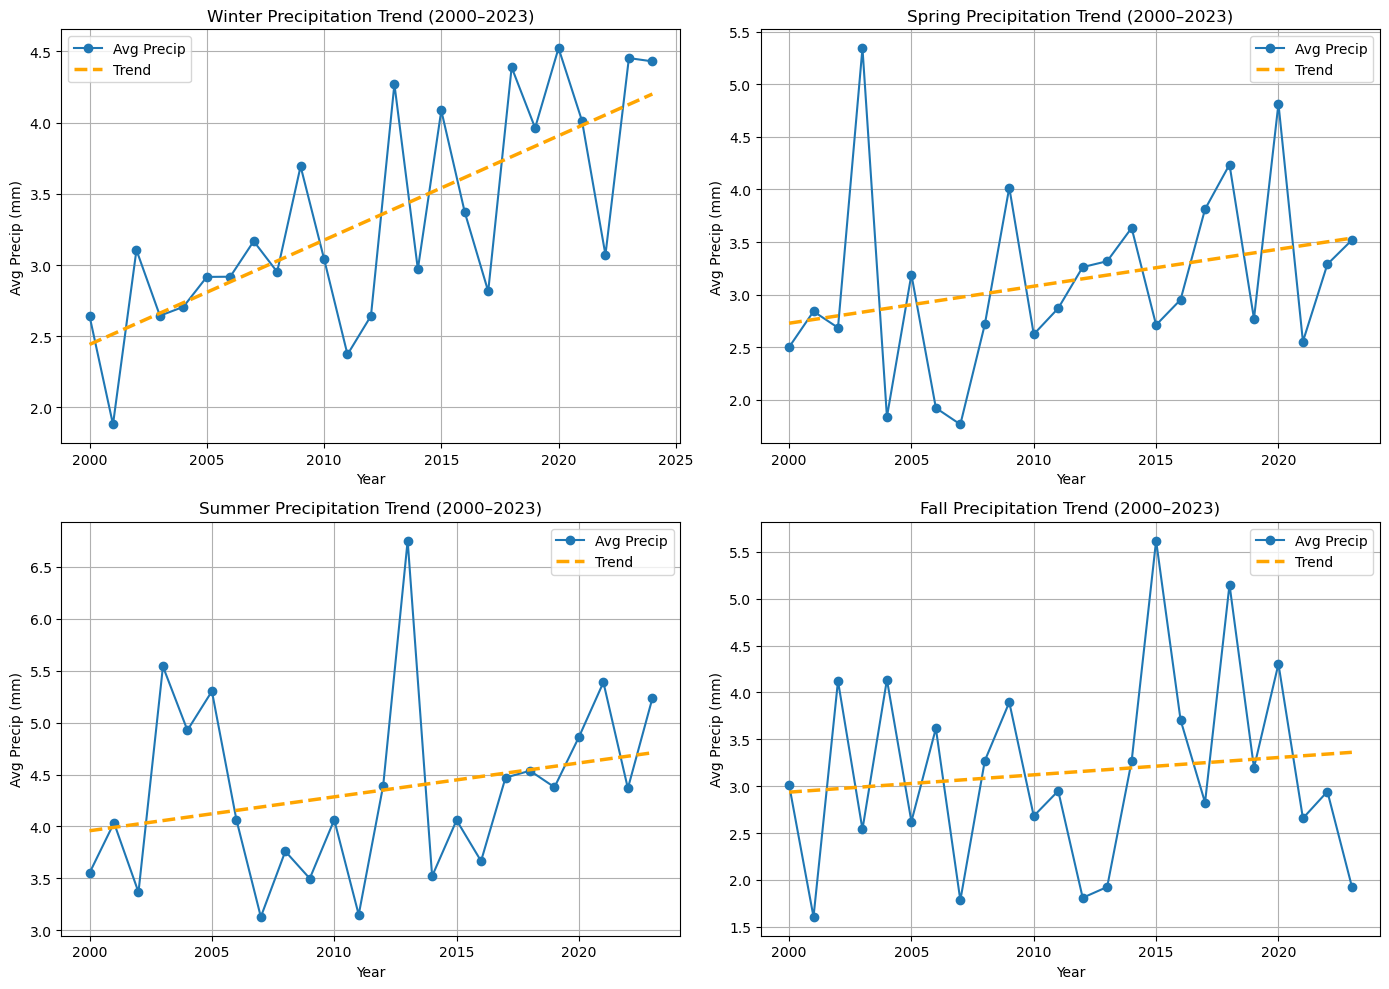

In [8]:
# Linear plots showing seasonal average precipitation trends from 2000–2023
seasonal_dfs = {
    'Winter': winter_df,
    'Spring': spring_df,
    'Summer': summer_df,
    'Fall': fall_df
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 layout for 4 seasons
axes = axes.flatten()

for idx, (season_name, df) in enumerate(seasonal_dfs.items()):
    seasonal_avg = df.groupby('Year')['pr(mm)'].mean()

    ax = axes[idx]
    
    ax.plot(seasonal_avg.index, seasonal_avg.values, marker='o', linestyle='-', label='Avg Precip')

    z = np.polyfit(seasonal_avg.index, seasonal_avg.values, 1)
    p = np.poly1d(z)
    ax.plot(seasonal_avg.index, p(seasonal_avg.index), linestyle='--', linewidth=2.5, color='orange', label='Trend')

    ax.set_xlabel("Year")
    ax.set_ylabel("Avg Precip (mm)")
    ax.set_title(f"{season_name} Precipitation Trend (2000–2023)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### VIF analysis: Measures multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

features = ["etr(mm)", "rmax(%)", "sph(kg/kg)", "srad(Wm-2)", "vs(mps)", "th(DegreesClockwisefromnorth)"]


seasonal_dfs = {
    'winter': winter_df,
    'spring': spring_df,
    'summer': summer_df,
    'fall': fall_df
}


for season, df in seasonal_dfs.items():
    X = df[features]

    # Add a constant for VIF calculation
    X_with_const = add_constant(X)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

## Seasonal Dataset Preparation

The seasonal datasets were sorted by date and climate region to preserve the temporal structure needed for classification modeling.

In [14]:
def prepare_seasonal_data(seasonal_data):
    """Sort seasonal datasets by climate region and date, then remove incomplete future-year records."""
    prepared_data = {}

    for season, df in seasonal_data.items():
        df = df.copy()

        df["Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])
        df = df.sort_values(by=["ClimateRegion", "Date"])
        df = df[df["Year"] != 2024]
        df = df.reset_index(drop=True)

        prepared_data[season] = df

    return prepared_data


seasonal_dfs_poly = prepare_seasonal_data(seasonal_dfs)
{season: df.shape for season, df in seasonal_dfs_poly.items()}

# Model training and validation 

## Monthly Classification Dataset Preparation

After seasonal modeling, monthly classification was tested because monthly grouping performed better. A binary precipitation target was created where `1` indicates precipitation and `0` indicates no precipitation.

In [ ]:
def prepare_monthly_classification_data(monthly_data):
    prepared_data = {}

    for month, df in monthly_data.items():
        df = df.copy()

        df["Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])
        df = df.sort_values(["ClimateRegion", "Date"]).reset_index(drop=True)

        df["precip"] = (df["pr(mm)"] > 0).astype(int)

        prepared_data[month] = df

    return prepared_data


monthly_dfs = prepare_monthly_classification_data(monthly_dfs)

In [ ]:
def add_lag_and_rolling_features(monthly_data, features, windows=[7, 14, 28]):
    monthly_data_features = {}

    for month, df in monthly_data.items():
        df = df.copy()

        for feature in features:
            df[f"{feature}_lag1"] = (
                df.groupby("ClimateRegion")[feature].shift(1)
            )

            for window in windows:
                df[f"{feature}_rolling{window}"] = (
                    df.groupby("ClimateRegion")[feature]
                    .transform(lambda x: x.shift(1).rolling(window).mean())
                )

        df = df.fillna(df.median(numeric_only=True))
        monthly_data_features[month] = df

    return monthly_data_features


main_features = ["etr(mm)", "rmax(%)", "sph(kg/kg)", "srad(Wm-2)", "vs(mps)"]

monthly_dfs_features = add_lag_and_rolling_features(
    monthly_dfs,
    features=main_features,
    windows=[7, 14, 28]
)

Lag and rolling-average features were tested to determine whether recent climate patterns improved classification performance. Lag-1 features produced a slight improvement, while additional rolling-average windows had limited impact.

## Random Forest Classification

Random Forest was used as the baseline classification model. Because the target variable was imbalanced, `class_weight="balanced"` was used. Model performance was evaluated using walk-forward validation, with F1 score used as the main selection metric.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid_rf = {
    "n_estimators": [100, 200, 500, 750],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", 0.5, 0.8]
}

tscv = TimeSeriesSplit(n_splits=5)
best_params_per_month_rf = {}

for month in range(1, 13):
    df = monthly_dfs_features[month]

    X = df.drop(columns=["pr(mm)", "Date", "precip"], errors="ignore")
    y = df["precip"]

    X = pd.get_dummies(X, columns=["ClimateRegion"], prefix="Region")

    rf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid_rf,
        n_iter=50,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    search.fit(X, y)
    best_params_per_month_rf[month] = search.best_params_

In [ ]:
def evaluate_classifier(y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="binary")
    }

In [ ]:
def walk_forward_rf_classifier(df, training_window, forecast_horizon, best_params):
    results = []

    for start in range(0, len(df) - training_window - forecast_horizon, forecast_horizon):
        train_df, test_df = split_data(df, start, training_window, forecast_horizon)

        X_train, X_test, y_train, y_test = prepare_classification_features(train_df, test_df)

        model = RandomForestClassifier(
            **best_params,
            random_state=42,
            class_weight="balanced"
        )

        model.fit(X_train, y_train)

        results.append(
            evaluate_classifier(
                y_train,
                model.predict(X_train),
                y_test,
                model.predict(X_test)
            )
        )

    return pd.DataFrame(results).mean()

In [ ]:
monthly_results_rf = {}

for month in range(1, 13):
    config = best_configs[month]

    monthly_results_rf[month] = walk_forward_rf_classifier(
        monthly_dfs_features[month],
        training_window=int(config["train_size"]),
        forecast_horizon=int(config["test_size"]),
        best_params=best_params_per_month_rf[month]
    )

rf_classification_summary = pd.DataFrame(monthly_results_rf).T
rf_classification_summary

## XGBoost Classification

XGBoost was tested after Random Forest because it can model non-linear relationships and handle class imbalance using `scale_pos_weight`. Hyperparameter tuning was performed using randomized search and time-series cross-validation.

In [ ]:
from xgboost import XGBClassifier
from collections import Counter

param_grid_xgb = {
    "n_estimators": [150, 250, 500, 750],
    "max_depth": [4, 6, 9],
    "learning_rate": [0.01, 0.03, 0.07, 0.15, 0.3],
    "subsample": [0.5, 0.6, 0.7, 0.9],
    "colsample_bytree": [0.5, 0.6],
    "gamma": [0, 0.1, 1, 2, 4, 7, 9],
    "reg_alpha": [0.01, 0.1, 0.7, 1, 3, 5, 7],
    "scale_pos_weight": [1, 1.5, 1.9, 2, 5, 10]
}

best_params_per_month_xgb = {}

for month in range(1, 13):
    df = monthly_dfs_features[month]

    X = df.drop(columns=["pr(mm)", "Date", "precip"], errors="ignore")
    y = df["precip"]

    X = pd.get_dummies(X, columns=["ClimateRegion"], prefix="Region")

    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid_xgb,
        n_iter=60,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    search.fit(X, y)
    best_params_per_month_xgb[month] = search.best_params_

In [ ]:
def prepare_classification_features(train_df, test_df):
    X_train = train_df.drop(columns=["pr(mm)", "Date", "precip"], errors="ignore")
    X_test = test_df.drop(columns=["pr(mm)", "Date", "precip"], errors="ignore")

    y_train = train_df["precip"]
    y_test = test_df["precip"]

    X_train = pd.get_dummies(X_train, columns=["ClimateRegion"], prefix="Region")
    X_test = pd.get_dummies(X_test, columns=["ClimateRegion"], prefix="Region")

    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    return X_train, X_test, y_train, y_test

In [ ]:
def walk_forward_xgb_classifier(df, training_window, forecast_horizon, best_params):
    results = []

    for start in range(0, len(df) - training_window - forecast_horizon, forecast_horizon):
        train_df, test_df = split_data(df, start, training_window, forecast_horizon)

        X_train, X_test, y_train, y_test = prepare_classification_features(train_df, test_df)

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            **best_params
        )

        model.fit(X_train, y_train)

        results.append(
            evaluate_classifier(
                y_train,
                model.predict(X_train),
                y_test,
                model.predict(X_test)
            )
        )

    return pd.DataFrame(results).mean()

In [ ]:
monthly_results_xgb = {}

for month in range(1, 13):
    config = best_configs[month]

    monthly_results_xgb[month] = walk_forward_xgb_classifier(
        monthly_dfs_features[month],
        training_window=int(config["train_size"]),
        forecast_horizon=int(config["test_size"]),
        best_params=best_params_per_month_xgb[month]
    )

xgb_classification_summary = pd.DataFrame(monthly_results_xgb).T
xgb_classification_summary

### Classification Results

Lag-1 features provided a slight improvement in classification performance. XGBoost with hyperparameter tuning produced the strongest classification results overall, outperforming the regression models from the previous notebook.

## Final XGBoost Classification on 2024 Data

The tuned XGBoost classifier was selected as the final classification model. It was trained on the historical monthly datasets and evaluated on 2024 precipitation data.

In [ ]:
def prepare_2024_monthly_data(monthly_2024):
    prepared_data = {}

    for month, df in monthly_2024.items():
        df = df.copy()

        df["Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])
        df = df.sort_values(["ClimateRegion", "Date"]).reset_index(drop=True)
        df["precip"] = (df["pr(mm)"] > 0).astype(int)

        prepared_data[month] = df

    return prepared_data


monthly_2024 = prepare_2024_monthly_data(monthly_2024)

In [ ]:
monthly_2024_features = add_lag_and_rolling_features(
    monthly_2024,
    features=main_features,
    windows=[]
)

In [ ]:
final_results_2024 = {}
all_predictions_2024 = []

for month in range(1, 13):
    train_df = monthly_dfs_features[month]
    test_df = monthly_2024_features[month]

    X_train, X_test, y_train, y_test = prepare_classification_features(
        train_df,
        test_df
    )

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        **best_params_per_month_xgb[month]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results_2024[month] = evaluate_classifier(
        y_train,
        model.predict(X_train),
        y_test,
        y_pred
    )

    predictions_df = pd.DataFrame({
        "Date": test_df["Date"],
        "Actual": y_test,
        "Predicted": y_pred,
        "Predicted Probability": y_prob,
        "Month": month
    })

    all_predictions_2024.append(predictions_df)

final_2024_summary = pd.DataFrame(final_results_2024).T
final_2024_summary

In [ ]:
predictions_2024 = pd.concat(all_predictions_2024, ignore_index=True)
predictions_2024.head()

## Final Classification Results

Hyperparameter tuning substantially improved XGBoost performance, making it the strongest-performing classification model evaluated in this study.

The final tuned model was trained on the historical climate data and used to generate precipitation predictions for the 2024 dataset. Monthly confusion matrices were created to visualize model performance, including true positives, true negatives, false positives, and false negatives across each month.

Support Vector Machine (SVM) classification was also evaluated as part of the study. Although it did not outperform Random Forest or XGBoost, its performance is included in the accompanying figures to provide a complete comparison of all classification models investigated.